In [46]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("https://cognitrilha.com.br/datasets/lojinha_bairro_vendas_abril_2026.csv.gz")
df2 = pd.read_csv("https://cognitrilha.com.br/datasets/lojinha_bairro_produtos_abril_2026.csv.gz")
df
df2.head()

,codigo_barras,produto,marca,preco
0,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90
1,7892604000028,Arroz Parboilizado 5kg,Graonoro,27.80
2,7892604000035,Feijao Carioca 1kg,Rancho Lume,8.49
3,7892604000042,Feijao Preto 1kg,Rancho Lume,8.79
4,7892604000059,Acucar Cristal 1kg,Docevia,4.59


In [47]:
df.head()

,data_hora,operador,produto_codigo_barras,quantidade,preco_unitario,forma_pagamento
0,2026-04-01 07:17:15,Ana Costa,7892604000448,3,4.59,Debito
1,2026-04-01 07:17:15,Ana Costa,7892604000837,1,9.99,Debito
2,2026-04-01 07:32:40,Marta Reis,7892604000745,1,8.49,Pix
3,2026-04-01 07:36:26,Ana Costa,7892604000028,5,27.80,Pix
4,2026-04-01 07:36:26,Ana Costa,7892604000035,5,8.49,Pix


In [48]:
df.tail()

,data_hora,operador,produto_codigo_barras,quantidade,preco_unitario,forma_pagamento
4395,2026-04-30 20:54:40,Carla Nunes,7892604001209,1,6.99,Pix
4396,2026-04-30 21:13:57,Carla Nunes,7892604000318,2,1.69,Debito
4397,2026-04-30 21:13:57,Carla Nunes,7892604000721,3,2.49,Debito
4398,2026-04-30 21:13:57,Carla Nunes,7892604000936,1,7.49,Debito
4399,2026-04-30 21:13:57,Carla Nunes,7892604001261,1,7.99,Debito


In [49]:
df['subtotal'] = df["quantidade"]* df["preco_unitario"]
df.head()

,data_hora,operador,produto_codigo_barras,quantidade,preco_unitario,forma_pagamento,subtotal
0,2026-04-01 07:17:15,Ana Costa,7892604000448,3,4.59,Debito,13.77
1,2026-04-01 07:17:15,Ana Costa,7892604000837,1,9.99,Debito,9.99
2,2026-04-01 07:32:40,Marta Reis,7892604000745,1,8.49,Pix,8.49
3,2026-04-01 07:36:26,Ana Costa,7892604000028,5,27.80,Pix,139.00
4,2026-04-01 07:36:26,Ana Costa,7892604000035,5,8.49,Pix,42.45


In [50]:
df["subtotal"].sum()

np.float64(52411.79)

In [51]:
df[df["operador"]=="Ana Costa"].sum()

,0
data_hora,2026-04-01 07:17:152026-04-01 07:17:152026-04-...
operador,Ana CostaAna CostaAna CostaAna CostaAna CostaA...
produto_codigo_barras,4285683972359853
quantidade,981
preco_unitario,3950.73
forma_pagamento,DebitoDebitoPixPixPixPixDebitoDebitoDebitoDebi...
subtotal,7175.66


In [52]:
df[df["forma_pagamento"]=="Pix"].sum()

,0
data_hora,2026-04-01 07:32:402026-04-01 07:36:262026-04-...
operador,Marta ReisAna CostaAna CostaAna CostaAna Costa...
produto_codigo_barras,15138014473291770
quantidade,3326
preco_unitario,13384.92
forma_pagamento,PixPixPixPixPixPixPixPixPixPixPixPixPixPixPixP...
subtotal,22550.66


In [53]:
df.groupby("forma_pagamento").size()

,0
forma_pagamento,
Credito,849
Debito,1112
Dinheiro,363
Pix,1918
Vale alimentacao,158


In [54]:
df.groupby("operador")["subtotal"].sum()

,subtotal
operador,
Ana Costa,7175.66
Bruno Lima,4833.05
Carla Nunes,10292.44
Diego Rocha,15623.73
Marta Reis,14486.91


<Axes: xlabel='operador'>

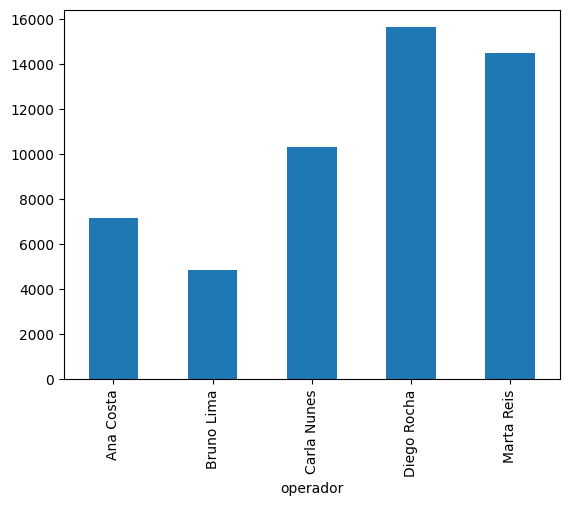

In [55]:
df.groupby("operador")["subtotal"].sum().plot.bar()

<Axes: ylabel='subtotal'>

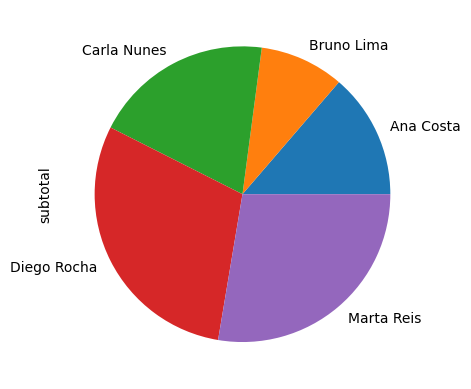

In [56]:
df.groupby("operador")["subtotal"].sum().plot.pie()

In [57]:
df_unificado = df.merge(df2, left_on="produto_codigo_barras", right_on="codigo_barras")
df_unificado.head()

,data_hora,operador,produto_codigo_barras,quantidade,preco_unitario,forma_pagamento,subtotal,codigo_barras,produto,marca,preco
0,2026-04-01 07:17:15,Ana Costa,7892604000448,3,4.59,Debito,13.77,7892604000448,Salgadinho Milho Queijo 90g,Crocancia,4.59
1,2026-04-01 07:17:15,Ana Costa,7892604000837,1,9.99,Debito,9.99,7892604000837,Bolo Fofo Laranja 300g,Fornalva,9.99
2,2026-04-01 07:32:40,Marta Reis,7892604000745,1,8.49,Pix,8.49,7892604000745,Presunto Fatiado 150g,Fatiobom,8.49
3,2026-04-01 07:36:26,Ana Costa,7892604000028,5,27.80,Pix,139.00,7892604000028,Arroz Parboilizado 5kg,Graonoro,27.80
4,2026-04-01 07:36:26,Ana Costa,7892604000035,5,8.49,Pix,42.45,7892604000035,Feijao Carioca 1kg,Rancho Lume,8.49


Mostre a quantidade de vendas agrupadas por marca (use groupby e size). Depois, exiba um gráfico de barras do resultado.

<Axes: ylabel='marca'>

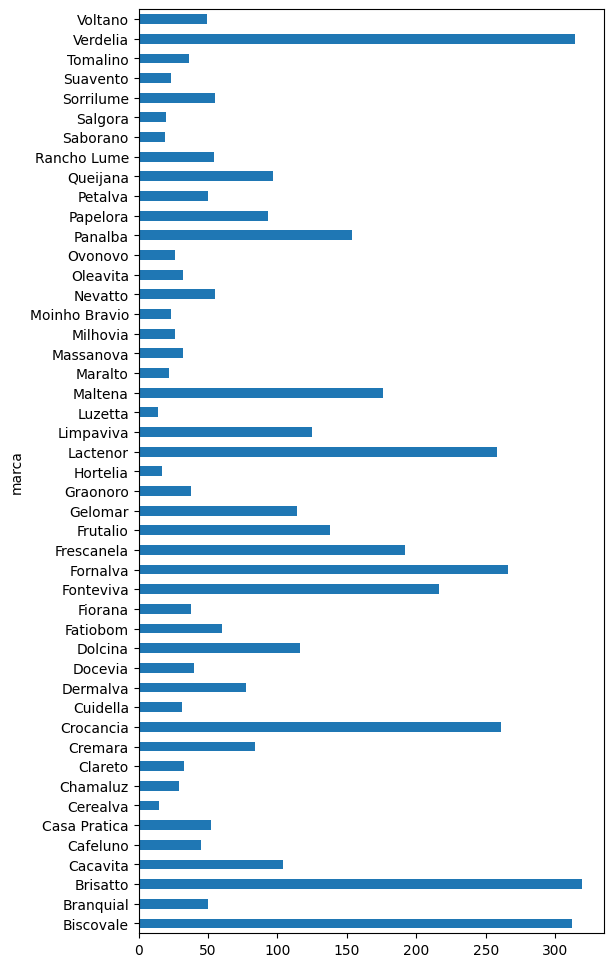

In [58]:
plt.figure(figsize=(6,12))
df_unificado.groupby("marca").size().plot.barh()

<Axes: ylabel='marca'>

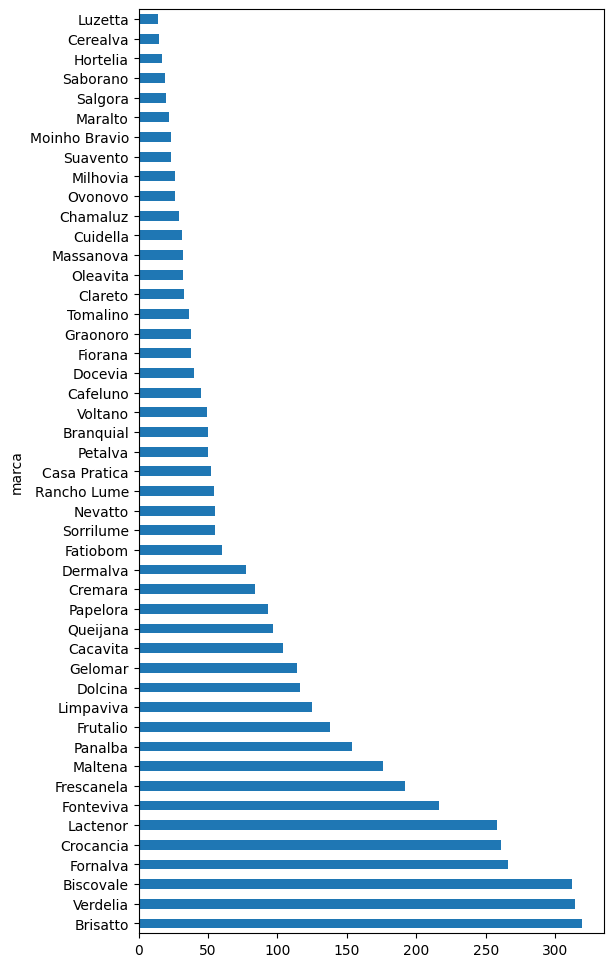

In [59]:
plt.figure(figsize=(6,12))
df_unificado.groupby("marca").size().sort_values(ascending=False).plot.barh()

In [ ]:
plt.figure(figsize=(6,12))
df_unificado.groupby("marca")["subtotal"].sum().plot.barh()